# Crimes violentos em Uberlândia (2019 a 2025)

Quantos crimes violentos a cidade registra por ano, quais tipos dominam e como o homicídio evoluiu.

Fonte: Banco de Crimes Violentos da SEJUSP (Secretaria de Estado de Justiça e Segurança Pública de MG), no portal de dados abertos do estado. O dado é mensal, por município e por tipo de crime.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print('ok')

ok


## 2. Carregar os dados

O arquivo `dados/crimes_violentos_uberlandia_2019_2025.csv` já está filtrado para a cidade (o passo a passo do download e do filtro está no README). Cada linha é um mês de um tipo de crime, com a quantidade de registros.

Detalhe de limpeza: o portal mudou a grafia dos nomes dos crimes de um ano para o outro (maiúsculas e minúsculas), então padronizo tudo antes de somar.

In [2]:
df = pd.read_csv('dados/crimes_violentos_uberlandia_2019_2025.csv')
import unicodedata
def sem_acento(t):
    return ''.join(c for c in unicodedata.normalize('NFKD', str(t)) if not unicodedata.combining(c))
df['natureza'] = df['natureza'].apply(lambda t: sem_acento(t).upper().strip())

total = df['registros'].sum()
print(f'{total:,.0f} registros de crimes violentos entre 2019 e 2025'.replace(',', '.'))
df.head(3)

12.707 registros de crimes violentos entre 2019 e 2025


,registros,natureza,municipio,cod_municipio,mes,ano,risp,rmbh
0,3,ESTUPRO CONSUMADO,UBERLANDIA,317020,1,2019,9,NÃO
1,5,ESTUPRO DE VULNERAVEL CONSUMADO,UBERLANDIA,317020,1,2019,9,NÃO
2,1,ESTUPRO DE VULNERAVEL TENTADO,UBERLANDIA,317020,1,2019,9,NÃO


## 3. O total por ano

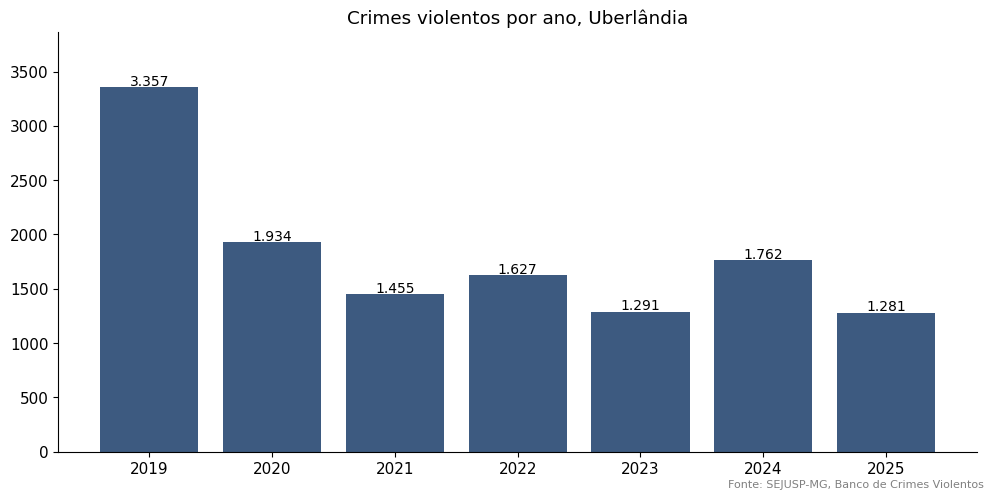

ano
2019    3357
2020    1934
2021    1455
2022    1627
2023    1291
2024    1762
2025    1281


In [3]:
por_ano = df.groupby('ano')['registros'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#3d5a80'] * len(por_ano)
ax.bar(por_ano.index, por_ano.values, color=cores)
ax.set_title('Crimes violentos por ano, Uberlândia')
for i, v in enumerate(por_ano.values):
    ax.text(por_ano.index[i], v + 15, f'{v:,.0f}'.replace(',', '.'), ha='center', fontsize=10)
ax.set_ylim(0, por_ano.max() * 1.15)
fig.text(0.99, 0.01, 'Fonte: SEJUSP-MG, Banco de Crimes Violentos', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/crimes_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()

print(por_ano.to_string())

## 4. Quais crimes entram na conta

O banco da SEJUSP cobre os crimes violentos letais e patrimoniais graves: roubo, homicídio, estupro, extorsão, sequestro e feminicídio. Furto não entra nesse banco (a SEJUSP publica o furto em outra base).

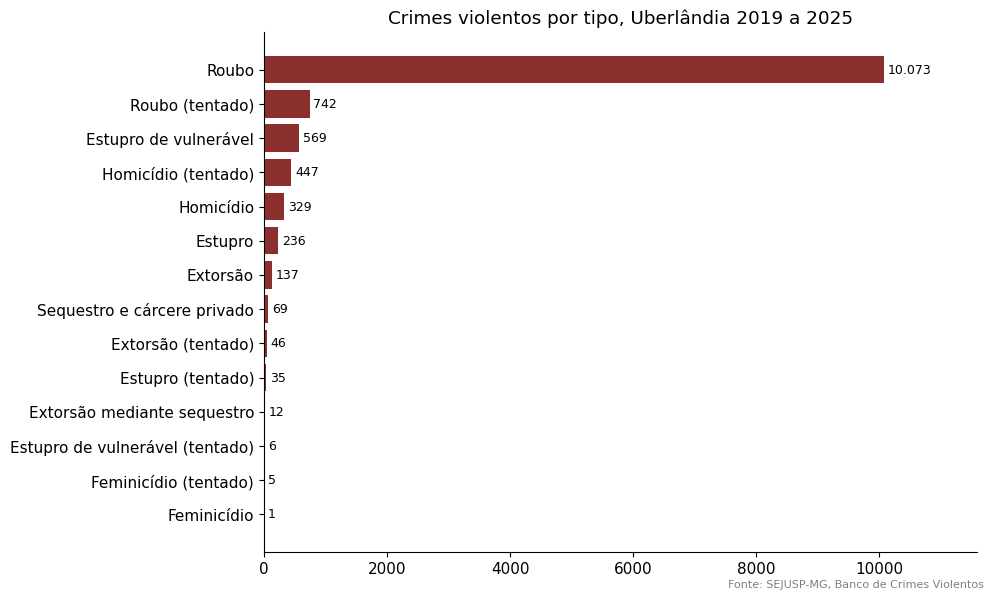

roubos (consumados e tentados) são 85% dos registros


In [4]:
rotulos = {
    'ROUBO CONSUMADO': 'Roubo',
    'ROUBO TENTADO': 'Roubo (tentado)',
    'HOMICIDIO CONSUMADO (REGISTROS)': 'Homicídio',
    'HOMICIDIO TENTADO': 'Homicídio (tentado)',
    'ESTUPRO DE VULNERAVEL CONSUMADO': 'Estupro de vulnerável',
    'ESTUPRO CONSUMADO': 'Estupro',
    'ESTUPRO DE VULNERAVEL TENTADO': 'Estupro de vulnerável (tentado)',
    'ESTUPRO TENTADO': 'Estupro (tentado)',
    'EXTORSAO CONSUMADO': 'Extorsão',
    'EXTORSAO TENTADO': 'Extorsão (tentado)',
    'EXTORSAO MEDIANTE SEQUESTRO CONSUMADO': 'Extorsão mediante sequestro',
    'SEQUESTRO E CARCERE PRIVADO CONSUMADO': 'Sequestro e cárcere privado',
    'SEQUESTRO E CARCERE PRIVADO TENTADO': 'Sequestro e cárcere privado (tentado)',
    'FEMINICIDIO CONSUMADO (REGISTROS)': 'Feminicídio',
    'FEMINICIDIO TENTADO': 'Feminicídio (tentado)',
}
df['crime'] = df['natureza'].map(rotulos)
por_crime = df.groupby('crime')['registros'].sum().sort_values()
por_crime = por_crime[por_crime > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(por_crime.index, por_crime.values, color='#8c2f2f')
ax.set_title('Crimes violentos por tipo, Uberlândia 2019 a 2025')
for i, v in enumerate(por_crime.values):
    ax.text(v + 60, i, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_xlim(0, por_crime.max() * 1.15)
fig.text(0.99, 0.01, 'Fonte: SEJUSP-MG, Banco de Crimes Violentos', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/crimes_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

roubo_pct = df[df['crime'].isin(['Roubo', 'Roubo (tentado)'])]['registros'].sum() / total * 100
print(f'roubos (consumados e tentados) são {roubo_pct:.0f}% dos registros')

## 5. Homicídios, ano a ano

Separo o crime mais grave para ver a tendência. E calculo a taxa por 100 mil habitantes, que é o jeito padrão de comparar cidades (uso a população do Censo 2022, 713.224 pessoas).

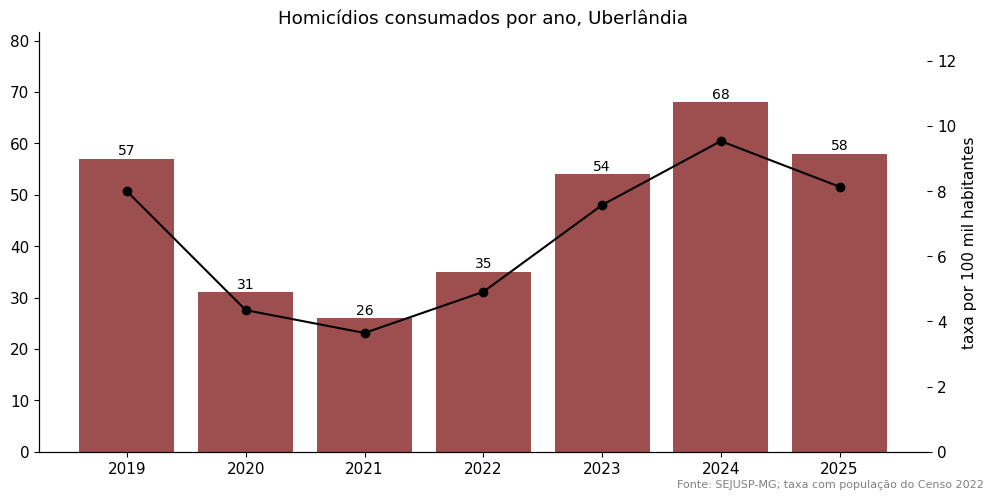

2019: 57 homicídios, taxa de 8.0 por 100 mil
2020: 31 homicídios, taxa de 4.3 por 100 mil
2021: 26 homicídios, taxa de 3.6 por 100 mil
2022: 35 homicídios, taxa de 4.9 por 100 mil
2023: 54 homicídios, taxa de 7.6 por 100 mil
2024: 68 homicídios, taxa de 9.5 por 100 mil
2025: 58 homicídios, taxa de 8.1 por 100 mil


In [5]:
hom = df[df['crime'] == 'Homicídio'].groupby('ano')['registros'].sum()
populacao = 713_224
taxa = hom / populacao * 100_000

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(hom.index, hom.values, color='#8c2f2f', alpha=0.85)
ax1.set_title('Homicídios consumados por ano, Uberlândia')
for i, v in enumerate(hom.values):
    ax1.text(hom.index[i], v + 0.8, str(v), ha='center', fontsize=10)
ax1.set_ylim(0, hom.max() * 1.2)
ax2 = ax1.twinx()
ax2.plot(taxa.index, taxa.values, color='black', marker='o', linewidth=1.5)
ax2.set_ylabel('taxa por 100 mil habitantes')
ax2.spines['top'].set_visible(False)
ax2.set_ylim(0, taxa.max() * 1.35)
fig.text(0.99, 0.01, 'Fonte: SEJUSP-MG; taxa com população do Censo 2022', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/homicidios_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()

for a in hom.index:
    print(f'{a}: {hom[a]} homicídios, taxa de {taxa[a]:.1f} por 100 mil')

## 6. Mês a mês nos últimos dois anos

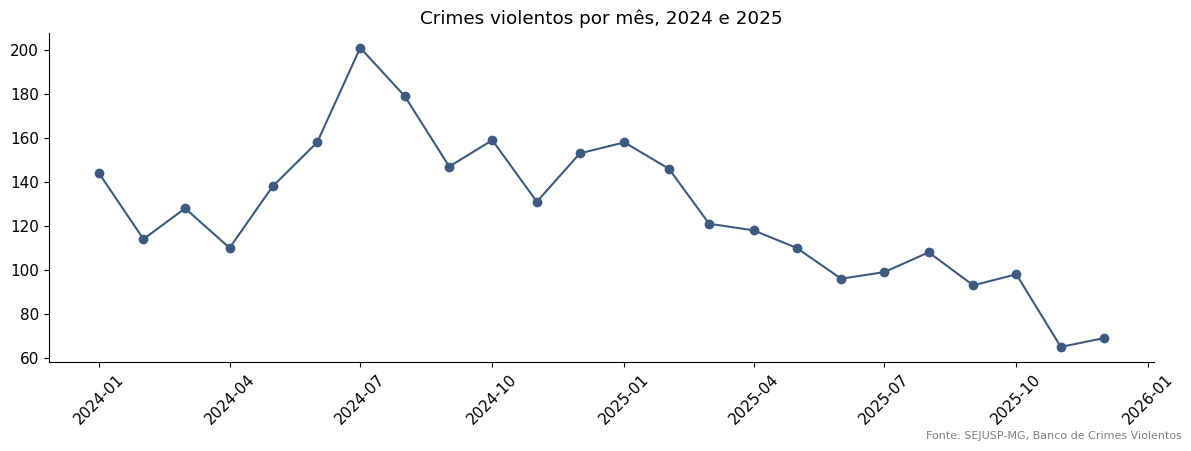

pior mês do período: 7/2024, com 201 registros


In [6]:
recente = df[df['ano'] >= 2024].groupby(['ano', 'mes'])['registros'].sum().reset_index()
recente['data'] = pd.to_datetime(dict(year=recente['ano'], month=recente['mes'], day=1))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(recente['data'], recente['registros'], marker='o', color='#3d5a80')
ax.set_title('Crimes violentos por mês, 2024 e 2025')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'.replace(',', '.')))
plt.xticks(rotation=45)
fig.text(0.99, 0.01, 'Fonte: SEJUSP-MG, Banco de Crimes Violentos', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/crimes_mes_a_mes.png', dpi=150, bbox_inches='tight')
plt.show()

pior_mes = recente.loc[recente['registros'].idxmax()]
print(f'pior mês do período: {pior_mes["mes"]:.0f}/{pior_mes["ano"]:.0f}, com {pior_mes["registros"]:.0f} registros')

## 7. O que eu tiro disso

Entre 2019 e 2025, Uberlândia registrou **12.707 crimes violentos**. A maior parte, de longe, é roubo: 85% dos registros (10.815 somando consumados e tentativas). É o crime que a população sente no dia a dia: celular, moto, carro, comércio.

Três coisas me chamaram atenção:

1. **2019 foi o pior ano do período**, com 3.357 registros. Depois o total caiu forte em 2020 (1.934) e nunca mais voltou àquele nível: desde 2021 a cidade oscila entre 1.281 e 1.762 registros por ano. 2025 fechou com 1.281, o menor número do período.
2. **O homicídio conta outra história.** Caiu de 57 (2019) para 26 (2021), mas voltou a subir até 68 em 2024, a pior marca do período, taxa de 9,5 por 100 mil habitantes. Em 2025 recuou para 58 (8,1 por 100 mil).
3. **O pior mês recente foi julho de 2024**, com 201 registros. A segunda metade de 2025 mostra queda consistente mês a mês.

Ressalvas: a base cobre só os crimes violentos da SEJUSP (roubo, homicídio, estupro, extorsão, sequestro e feminicídio); furto, tráfico e crimes de trânsito ficam em outras bases. E são registros de ocorrência, que dependem de a vítima procurar a polícia (crimes como estupro têm subnotificação conhecida).